In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

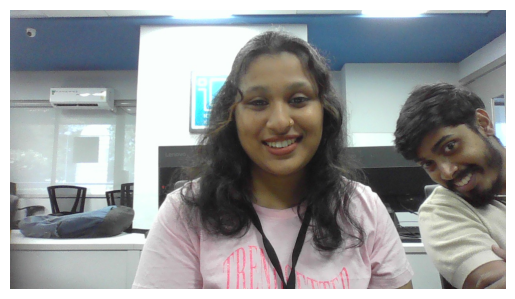

In [ ]:
img_path = '/content/WIN_20260204_13_56_28_Pro.jpg'  # change only if name differs
img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")


In [ ]:
image = np.array(img)

print(type(image))
print(image.shape)


<class 'numpy.ndarray'>
(720, 1280, 3)


In [ ]:
h, w, c = image.shape
pixels = image.reshape(-1, 3)

print("pixels shape:", pixels.shape)


pixels shape: (921600, 3)


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(pixels)

print("Unique labels:", np.unique(kmeans_labels))


Unique labels: [0 1]


In [ ]:
segmented_kmeans = pixels.copy()
segmented_kmeans[kmeans_labels == 0] = [0, 0, 0]
segmented_kmeans[kmeans_labels == 1] = [255, 255, 255]

segmented_kmeans = segmented_kmeans.reshape(h, w, 3)



(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

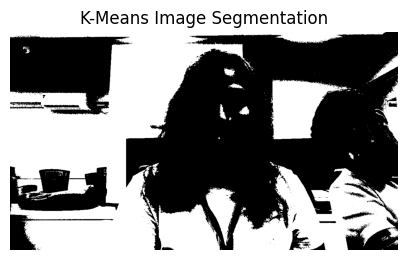

In [ ]:
plt.figure(figsize=(5,5))
plt.imshow(segmented_kmeans)
plt.title("K-Means Image Segmentation")
plt.axis("off")


In [ ]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from PIL import Image

# --- Steps to define 'img' (copied from tmAM0cWw_vDE) ---
img_path = '/content/WIN_20260204_13_56_28_Pro.jpg'  # change only if name differs
img = Image.open(img_path)
# ----------------------------------------------------------

img_small = img.resize((100, 100))
img_data = np.array(img_small).reshape(-1, 3)

hc = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(img_data)

print(f"Successfully clustered {img_data.shape[0]} pixels.")

Successfully clustered 10000 pixels.


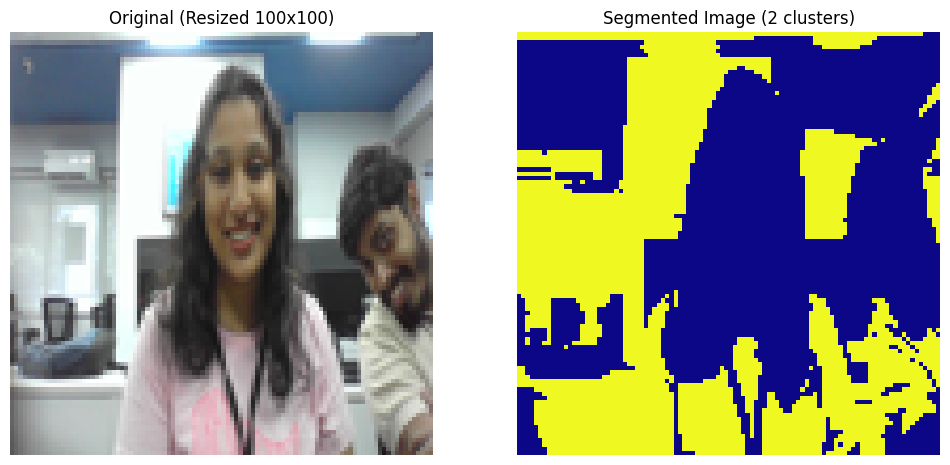

In [ ]:
import matplotlib.pyplot as plt

segmented_img = y_hc.reshape(100, 100)

plt.figure(figsize=(12, 6))


plt.subplot(1, 2, 1)
plt.imshow(img_small)
plt.title('Original (Resized 100x100)')
plt.axis('off')


plt.subplot(1, 2, 2)

plt.imshow(segmented_img, cmap='plasma')
plt.title('Segmented Image (2 clusters)')
plt.axis('off')

plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
silhouette_score = silhouette_score(img_data, y_hc)
print(f"Silhouette Score: {silhouette_score}")

Silhouette Score: 0.6103947885202357


Estimated number of clusters: 3
Estimated number of noise points: 59


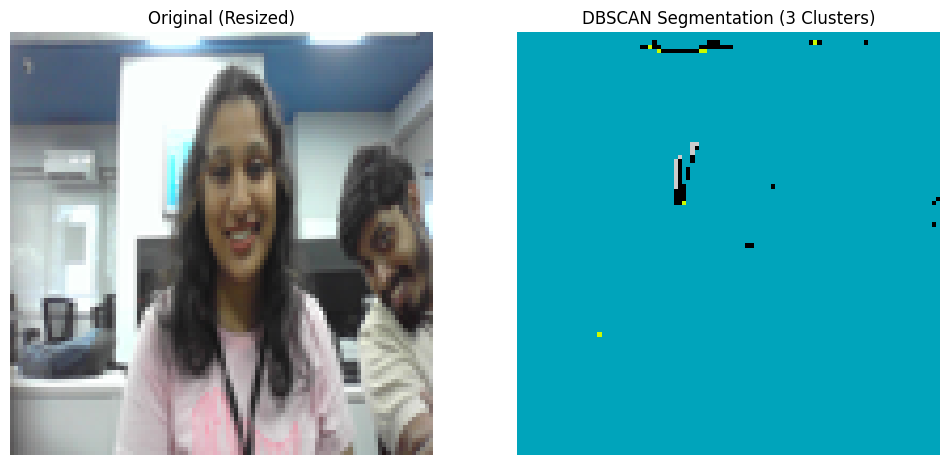

In [ ]:
import numpy as np
from sklearn.cluster import DBSCAN
from PIL import Image
import matplotlib.pyplot as plt


img_path = '/content/WIN_20260204_13_56_28_Pro.jpg'
img = Image.open(img_path)
img_small = img.resize((100, 100))
img_data = np.array(img_small).reshape(-1, 3)

db = DBSCAN(eps=13.5, min_samples=10)
y_db = db.fit_predict(img_data)

segmented_db = y_db.reshape(100, 100)


n_clusters_ = len(set(y_db)) - (1 if -1 in y_db else 0)
n_noise_ = list(y_db).count(-1)

print(f'Estimated number of clusters: {n_clusters_}')
print(f'Estimated number of noise points: {n_noise_}')


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_small)
plt.title('Original (Resized)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(segmented_db, cmap='nipy_spectral')
plt.title(f'DBSCAN Segmentation ({n_clusters_} Clusters)')
plt.axis('off')

plt.show()

Total pixels: 921600
Sampled pixels: 308


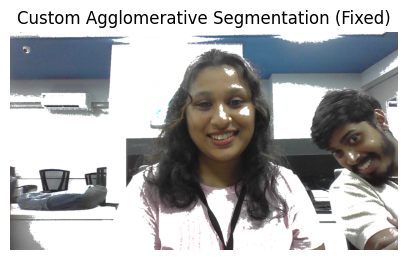

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.spatial.distance import cdist

# ==================================================
# 1. LOAD IMAGE & PREPARE DATA
# ==================================================
img = Image.open('/content/WIN_20260204_13_56_28_Pro.jpg')  # change path if needed
image = np.array(img)

h, w, c = image.shape
img_data = image.reshape(-1, 3)

print("Total pixels:", img_data.shape[0])

# ==================================================
# 2. AGGRESSIVE SAMPLING (REQUIRED FOR SPEED)
# ==================================================
STEP = 3000                      # ~300 pixels
img_data_small = img_data[::STEP]

print("Sampled pixels:", img_data_small.shape[0])

# ==================================================
# 3. CUSTOM AGGLOMERATIVE CLUSTERING
# ==================================================
def custom_agglomerative(data, n_clusters=2):
    clusters = [[i] for i in range(len(data))]
    centroids = data.copy()

    while len(clusters) > n_clusters:
        dist = cdist(centroids, centroids)
        np.fill_diagonal(dist, np.inf)

        i, j = np.unravel_index(np.argmin(dist), dist.shape)

        clusters[i].extend(clusters[j])
        clusters.pop(j)

        centroids[i] = np.mean(data[clusters[i]], axis=0)
        centroids = np.delete(centroids, j, axis=0)

    labels = np.zeros(len(data), dtype=int)
    for idx, cluster in enumerate(clusters):
        for p in cluster:
            labels[p] = idx

    return labels

# ==================================================
# 4. CUSTOM DBSCAN
# ==================================================
def custom_dbscan(data, eps=15, min_samples=5):
    n = len(data)
    labels = np.full(n, -1)
    visited = np.zeros(n, dtype=bool)
    cluster_id = 0

    def region_query(i):
        return np.where(np.linalg.norm(data - data[i], axis=1) <= eps)[0]

    for i in range(n):
        if visited[i]:
            continue

        visited[i] = True
        neighbors = region_query(i)

        if len(neighbors) < min_samples:
            labels[i] = -1
        else:
            labels[i] = cluster_id
            queue = list(neighbors)

            while queue:
                j = queue.pop(0)
                if not visited[j]:
                    visited[j] = True
                    new_neighbors = region_query(j)
                    if len(new_neighbors) >= min_samples:
                        queue.extend(new_neighbors)

                if labels[j] == -1:
                    labels[j] = cluster_id

            cluster_id += 1

    return labels

# ==================================================
# 5. NEAREST-COLOR LABEL MAPPING (FIXES STRIPES)
# ==================================================
def map_labels_by_nearest_color(full_data, sample_data, sample_labels):
    mapped_labels = np.zeros(len(full_data), dtype=int)

    for i in range(len(full_data)):
        distances = np.linalg.norm(sample_data - full_data[i], axis=1)
        mapped_labels[i] = sample_labels[np.argmin(distances)]

    return mapped_labels

# ==================================================
# 6. MASK SMALLER CLUSTER (AGGLOMERATIVE)
# ==================================================
def mask_smaller_cluster(data, labels, mask_color=[255, 255, 255]):
    unique, counts = np.unique(labels, return_counts=True)
    smaller_cluster = unique[np.argmin(counts)]

    masked = data.copy()
    masked[labels == smaller_cluster] = mask_color
    return masked

# ==================================================
# 7. APPLY CUSTOM AGGLOMERATIVE
# ==================================================
labels_cagg_small = custom_agglomerative(img_data_small)
labels_cagg = map_labels_by_nearest_color(
    img_data, img_data_small, labels_cagg_small
)

img_cagg = mask_smaller_cluster(img_data, labels_cagg)
img_cagg = img_cagg.reshape(h, w, 3)

plt.figure(figsize=(5,5))
plt.imshow(img_cagg)
plt.title("Custom Agglomerative Segmentation (Fixed)")
plt.axis("off")
plt.show()

# ==================================================
# 8. APPLY CUSTOM DBSCAN
# ==================================================
labels_cdb_small = custom_dbscan(img_data_small)
labels_cdb = map_labels_by_nearest_color(
    img_data, img_data_small, labels_cdb_small
)

img_cdb = img_data.copy()
img_cdb[labels_cdb != 0] = [255, 255, 255]
img_cdb = img_cdb.reshape(h, w, 3)

plt.figure(figsize=(5,5))
plt.imshow(img_cdb)
plt.title("Custom DBSCAN Segmentation (Fixed)")
plt.axis("off")
plt.show()
